# 05 — Credit Risk Analysis

Evaluate the leakage-safe multiclass credit-risk model. The risk model explicitly excludes observed `credit_score` and derived `credit_strength` from inference.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print('Project root:', ROOT)

Project root: c:\Users\Dinesh more\OneDrive\Desktop\bank-loan-credit-risk-analysis\bank-loan-credit-risk-analysis


In [2]:
import json
import joblib
import pandas as pd
import numpy as np

from src.pipeline_utils import clean_common, feature_frame, CONFIG

models = {
    'loan_amount': joblib.load(ROOT/'models/loan_amount.joblib'),
    'loan_approval': joblib.load(ROOT/'models/loan_approval.joblib'),
    'credit_score': joblib.load(ROOT/'models/credit_score.joblib'),
    'credit_risk': joblib.load(ROOT/'models/credit_risk.joblib'),
}
print('Loaded:', ', '.join(models))

c:\Users\Dinesh more\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Dinesh more\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Dinesh more\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.8.0 when using version 1.7.2. This might lead 

Loaded: loan_amount, loan_approval, credit_score, credit_risk


c:\Users\Dinesh more\anaconda3\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

risk=clean_common(pd.read_csv(ROOT/'data/raw/credit_risk_data.csv'))
X=feature_frame(risk, CONFIG['features']['credit_risk']).drop(columns=['credit_score','credit_strength'],errors='ignore')
le=models['credit_risk']['label_encoder']
y=le.transform(risk.risk_level)
_, X_test, _, y_test=train_test_split(X,y,test_size=.20,random_state=42,stratify=y)
pred=models['credit_risk']['pipeline'].predict(X_test)
probs=models['credit_risk']['pipeline'].predict_proba(X_test)
print('Classes:',list(le.classes_))
print('Accuracy:',accuracy_score(y_test,pred))
print('Macro F1:',f1_score(y_test,pred,average='macro'))
print('Confusion matrix:\n',confusion_matrix(y_test,pred))
print(classification_report(y_test,pred,target_names=le.classes_))

Classes: ['High', 'Low', 'Medium']
Accuracy: 0.8179166666666666
Macro F1: 0.5779510627189675
Confusion matrix:
 [[1625    0  165]
 [   4   13   73]
 [ 186    9  325]]
              precision    recall  f1-score   support

        High       0.90      0.91      0.90      1790
         Low       0.59      0.14      0.23        90
      Medium       0.58      0.62      0.60       520

    accuracy                           0.82      2400
   macro avg       0.69      0.56      0.58      2400
weighted avg       0.81      0.82      0.81      2400



In [4]:
# Leakage-independence smoke test: change observed credit score while keeping all risk features fixed.
# Because credit_score is excluded, probabilities should remain identical.
row=risk.iloc[[0]].copy()
row_low=row.copy(); row_low['credit_score']=350
row_high=row.copy(); row_high['credit_score']=850
X_low=feature_frame(row_low,CONFIG['features']['credit_risk']).drop(columns=['credit_score','credit_strength'],errors='ignore')
X_high=feature_frame(row_high,CONFIG['features']['credit_risk']).drop(columns=['credit_score','credit_strength'],errors='ignore')
p_low=models['credit_risk']['pipeline'].predict_proba(X_low)[0]
p_high=models['credit_risk']['pipeline'].predict_proba(X_high)[0]
print('Probabilities identical:', np.allclose(p_low,p_high))
print('Low-score probabilities:', dict(zip(le.classes_,p_low)))
print('High-score probabilities:', dict(zip(le.classes_,p_high)))

Probabilities identical: True
Low-score probabilities: {'High': np.float64(0.9888332819306787), 'Low': np.float64(0.0), 'Medium': np.float64(0.011166718069321315)}
High-score probabilities: {'High': np.float64(0.9888332819306787), 'Low': np.float64(0.0), 'Medium': np.float64(0.011166718069321315)}


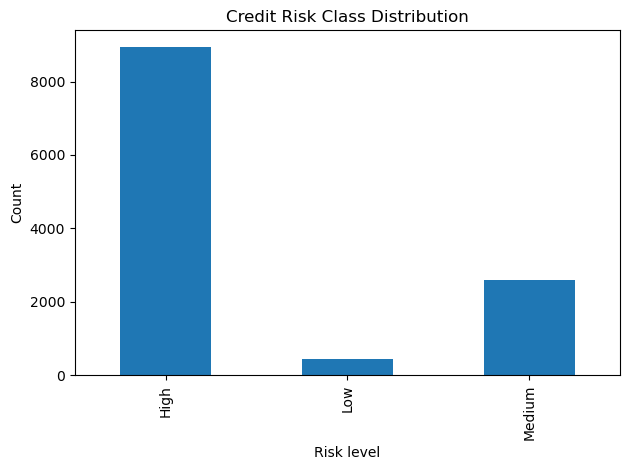

In [5]:
import matplotlib.pyplot as plt
counts=risk.risk_level.value_counts().reindex(le.classes_)
counts.plot(kind='bar',title='Credit Risk Class Distribution')
plt.xlabel('Risk level'); plt.ylabel('Count'); plt.tight_layout(); plt.show()

## Leakage note
The risk target must not be reconstructed from observed credit score or other post-outcome fields. Production training in `src/train.py` and inference in `src/predict.py` enforce this design.